<a href="https://colab.research.google.com/github/sjohn214/Colab-Repos/blob/NNRegressions/NN_Model_for_Regression_SLP.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Fourth Neural Model for Regression Analysis of Boston Housing Data Set

#### Step 1) Import Libraries

In [ ]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers
import numpy as np
import pandas as pd

#### Step 2) Import Boston Housing Data Set from Keras

In [ ]:
from tensorflow.keras.datasets import boston_housing
(train_data, train_targets), (test_data, test_targets) = boston_housing.load_data()

57026/57026 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [ ]:
train_df = pd.DataFrame(train_data) # creating train-df DataFrame

# Test Target Data Set Pre-processing for Plotting

In [ ]:
test_tg = test_targets.reshape(102)

test_tg_df = pd.DataFrame(test_tg) # creating a DataFrame from test_targets data set
test_tg_df.head()

,0
0,7.2
1,18.8
2,19.0
3,27.0
4,22.2


#### Training Data Set

In [ ]:
train_df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,1.23247,0.0,8.14,0.0,0.538,6.142,91.7,3.9769,4.0,307.0,21.0,396.90,18.72
1,0.02177,82.5,2.03,0.0,0.415,7.610,15.7,6.2700,2.0,348.0,14.7,395.38,3.11
2,4.89822,0.0,18.10,0.0,0.631,4.970,100.0,1.3325,24.0,666.0,20.2,375.52,3.26
3,0.03961,0.0,5.19,0.0,0.515,6.037,34.5,5.9853,5.0,224.0,20.2,396.90,8.01
4,3.69311,0.0,18.10,0.0,0.713,6.376,88.4,2.5671,24.0,666.0,20.2,391.43,14.65


In [ ]:
train_column_names = train_df.columns.tolist()

In [ ]:
print(train_column_names)

[0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]


In [21]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


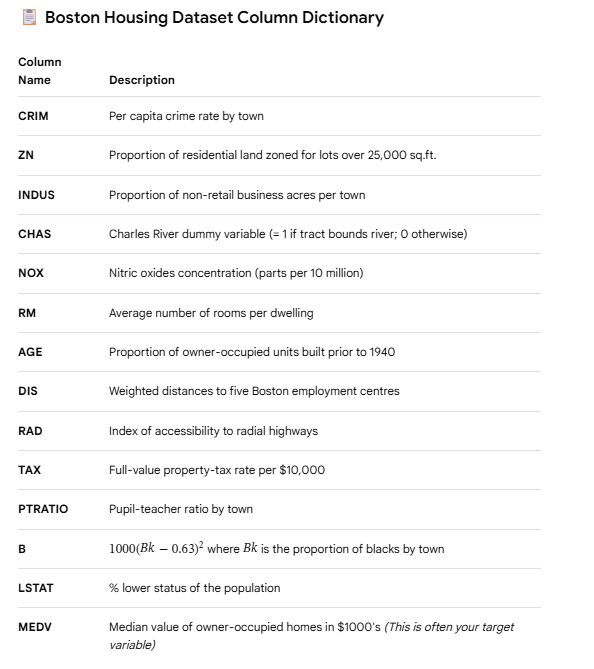

In [ ]:
import os
for dirname, _, filenames in os.walk('/kaggle/input'):
  for filename in filenames:
    print(os.path.join(dirname, filename))
from IPython.display import Image
Image(filename='/content/sample_data/boston_housing_column_names.png')


## Import Boston Housing Data in CSV Format to view column names

In [25]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

%matplotlib inline

# Define the official column names
column_names = ['CRIM', 'ZN', 'INDUS', 'CHAS', 'NOX', 'RM', 'AGE', 'DIS', 'RAD', 'TAX', 'PTRATIO', 'B', 'LSTAT']

# Convert your existing train_data numpy array into a DataFrame
train_data_df_csv = pd.DataFrame(train_data, columns=column_names)

# Add the target price column to the DataFrame
train_data_df_csv['MEDV'] = train_targets

# Display the data
train_data_df_csv.head()


,CRIM,ZN,INDUS,CHAS,NOX,RM,AGE,DIS,RAD,TAX,PTRATIO,B,LSTAT,MEDV
0,1.23247,0.0,8.14,0.0,0.538,6.142,91.7,3.9769,4.0,307.0,21.0,396.90,18.72,15.2
1,0.02177,82.5,2.03,0.0,0.415,7.610,15.7,6.2700,2.0,348.0,14.7,395.38,3.11,42.3
2,4.89822,0.0,18.10,0.0,0.631,4.970,100.0,1.3325,24.0,666.0,20.2,375.52,3.26,50.0
3,0.03961,0.0,5.19,0.0,0.515,6.037,34.5,5.9853,5.0,224.0,20.2,396.90,8.01,21.1
4,3.69311,0.0,18.10,0.0,0.713,6.376,88.4,2.5671,24.0,666.0,20.2,391.43,14.65,17.7


In [26]:
# 1. Calculate mean and standard deviation from the TRAINING data only
mean = train_data.mean(axis=0)
std = train_data.std(axis=0)

# 2. Apply the equation: z = (x - mean) / std
train_data_scaled = (train_data - mean) / std

# 3. Scale test data using the TRAINING mean and std (prevents data leakage)
test_data_scaled = (test_data - mean) / std

print("Original first row:", train_data[0])
print("Standardized first row:", train_data_scaled[0])


Original first row: [  1.23247   0.        8.14      0.        0.538     6.142    91.7
   3.9769    4.      307.       21.      396.9      18.72   ]
Standardized first row: [-0.27224633 -0.48361547 -0.43576161 -0.25683275 -0.1652266  -0.1764426
  0.81306188  0.1166983  -0.62624905 -0.59517003  1.14850044  0.44807713
  0.8252202 ]


<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\s'
<>:13: SyntaxWarning: invalid escape sequence '\m'
<>:14: SyntaxWarning: invalid escape sequence '\s'
<>:15: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_1075/2232054108.py:13: SyntaxWarning: invalid escape sequence '\m'
  plt.axvline(0, color='crimson', linestyle='-', linewidth=2, label='Mean ($\mu = 0$)')
/tmp/ipykernel_1075/2232054108.py:14: SyntaxWarning: invalid escape sequence '\s'
  plt.axvline(1, color='blue', linestyle='--', linewidth=1.5, label='+1 Std Dev ($\sigma = 1$)')
/tmp/ipykernel_1075/2232054108.py:15: SyntaxWarning: invalid escape sequence '\s'
  plt.axvline(-1, color='green', linestyle='--', linewidth=1.5, label='-1 Std Dev ($\sigma = -1$)')


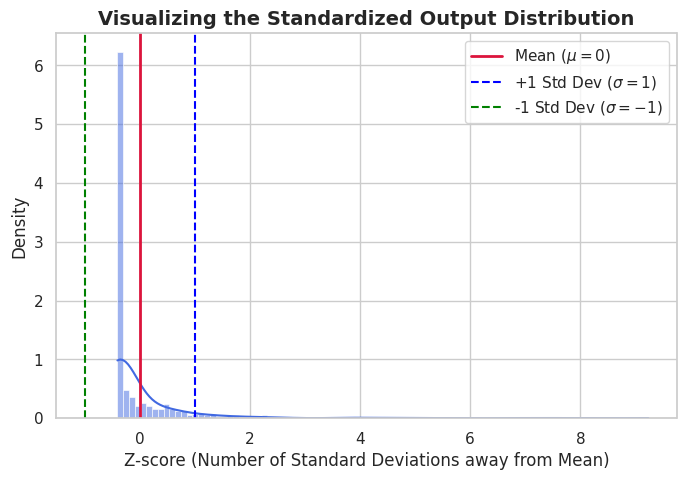

In [27]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set the plotting style
sns.set_theme(style="whitegrid")
plt.figure(figsize=(8, 5))

# Plot the distribution of the first standardized feature (CRIM - Crime Rate)
# train_data_scaled[:, 0] selects the entire first column
sns.histplot(train_data_scaled[:, 0], kde=True, color='royalblue', stat="density")

# Add visual lines for the mean and standard deviations
plt.axvline(0, color='crimson', linestyle='-', linewidth=2, label='Mean ($\mu = 0$)')
plt.axvline(1, color='blue', linestyle='--', linewidth=1.5, label='+1 Std Dev ($\sigma = 1$)')
plt.axvline(-1, color='green', linestyle='--', linewidth=1.5, label='-1 Std Dev ($\sigma = -1$)')

# Labels and Title
plt.title('Visualizing the Standardized Output Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Z-score (Number of Standard Deviations away from Mean)')
plt.ylabel('Density')
plt.legend()

plt.show()


### Using Normalized Train data set and Visualizing data set characteristics

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
train_data_df = pd.DataFrame(train_data)
train_data_df.head()

,0,1,2,3,4,5,6,7,8,9,10,11,12
0,1.23247,0.0,8.14,0.0,0.538,6.142,91.7,3.9769,4.0,307.0,21.0,396.90,18.72
1,0.02177,82.5,2.03,0.0,0.415,7.610,15.7,6.2700,2.0,348.0,14.7,395.38,3.11
2,4.89822,0.0,18.10,0.0,0.631,4.970,100.0,1.3325,24.0,666.0,20.2,375.52,3.26
3,0.03961,0.0,5.19,0.0,0.515,6.037,34.5,5.9853,5.0,224.0,20.2,396.90,8.01
4,3.69311,0.0,18.10,0.0,0.713,6.376,88.4,2.5671,24.0,666.0,20.2,391.43,14.65


<Axes: xlabel='5', ylabel='Count'>

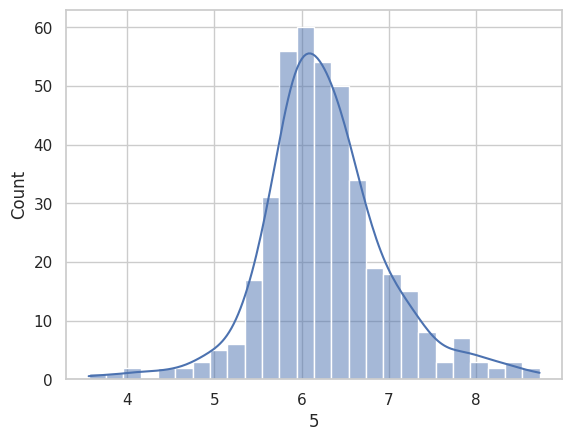

In [33]:
sns.histplot(train_data_df, x=5, kde=True)

<Axes: xlabel='2', ylabel='12'>

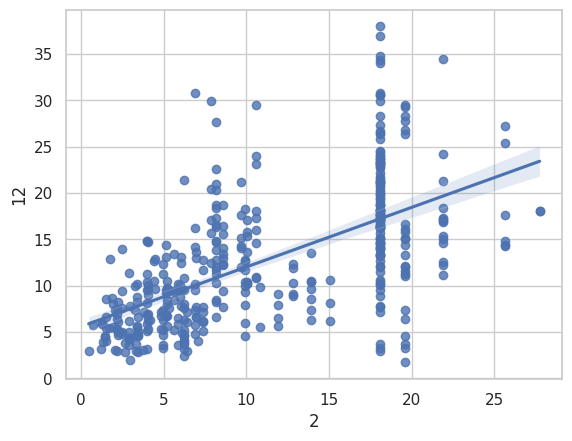

In [34]:
sns.regplot(x=train_data_df[2], y = train_data_df[12])

<Axes: xlabel='12', ylabel='Count'>

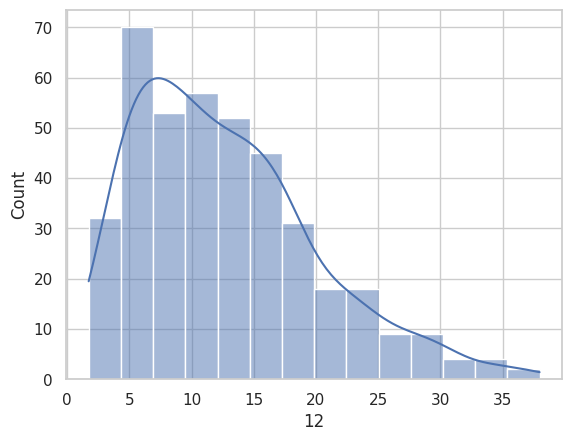

In [35]:
sns.histplot(train_data_df, x=12, kde=True)

In [31]:
# Create a summary table to check scaling metrics for each feature
metrics_df = pd.DataFrame({
    'Feature Index': range(train_data_scaled.shape[1]),
    'Mean': np.round(train_data_scaled.mean(axis=0), 4),
    'Std Dev': np.round(train_data_scaled.std(axis=0), 4),
    'Min': np.round(train_data_scaled.min(axis=0), 4),
    'Max': np.round(train_data_scaled.max(axis=0), 4)
})

print("--- Scaled Training Data Metrics ---")
print(metrics_df.to_string(index=False))


--- Scaled Training Data Metrics ---
 Feature Index  Mean  Std Dev     Min    Max
             0  -0.0      1.0 -0.4051 9.2348
             1   0.0      1.0 -0.4836 3.7290
             2   0.0      1.0 -1.5647 2.4454
             3  -0.0      1.0 -0.2568 3.8936
             4  -0.0      1.0 -1.4713 2.6773
             5   0.0      1.0 -3.8173 3.4672
             6   0.0      1.0 -2.3690 1.1105
             7   0.0      1.0 -1.2875 3.4374
             8   0.0      1.0 -0.9716 1.6759
             9  -0.0      1.0 -1.3113 1.8361
            10   0.0      1.0 -2.6738 1.6035
            11   0.0      1.0 -3.7711 0.4481
            12   0.0      1.0 -1.5197 3.4820


In [32]:
from tensorflow.keras import models
from tensorflow.keras import layers

def build_model():
    # 1. Define a Sequential architecture
    model = models.Sequential()

    # 2. Input layer + First Hidden layer (64 units, ReLU activation)
    # shape[1] dynamically sets the input dimensions to your 13 features
    model.add(layers.Dense(64, activation='relu', input_shape=(train_data_scaled.shape[1],)))

    # 3. Second Hidden layer (64 units, ReLU activation)
    model.add(layers.Dense(64, activation='relu'))

    # 4. Output layer (1 unit for continuous price prediction, no activation)
    model.add(layers.Dense(1))

    # 5. Compile the network metrics
    model.compile(optimizer='rmsprop',
                  loss='mse',
                  metrics=['mae'])

    return model

# Instantiate and look at the structural layout of model
model = build_model()
model.summary()


/usr/local/lib/python3.13/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 64)             │         4,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 5,121 (20.00 KB)

 Trainable params: 5,121 (20.00 KB)

 Non-trainable params: 0 (0.00 B)

### Training Target Data Set

In [36]:
import pandas as pd
targets_df = pd.DataFrame(train_targets)
targets_df.head()

,0
0,15.2
1,42.3
2,50.0
3,21.1
4,17.7


In [37]:
train_targets

array([15.2, 42.3, 50. , 21.1, 17.7, 18.5, 11.3, 15.6, 15.6, 14.4, 12.1,
       17.9, 23.1, 19.9, 15.7,  8.8, 50. , 22.5, 24.1, 27.5, 10.9, 30.8,
       32.9, 24. , 18.5, 13.3, 22.9, 34.7, 16.6, 17.5, 22.3, 16.1, 14.9,
       23.1, 34.9, 25. , 13.9, 13.1, 20.4, 20. , 15.2, 24.7, 22.2, 16.7,
       12.7, 15.6, 18.4, 21. , 30.1, 15.1, 18.7,  9.6, 31.5, 24.8, 19.1,
       22. , 14.5, 11. , 32. , 29.4, 20.3, 24.4, 14.6, 19.5, 14.1, 14.3,
       15.6, 10.5,  6.3, 19.3, 19.3, 13.4, 36.4, 17.8, 13.5, 16.5,  8.3,
       14.3, 16. , 13.4, 28.6, 43.5, 20.2, 22. , 23. , 20.7, 12.5, 48.5,
       14.6, 13.4, 23.7, 50. , 21.7, 39.8, 38.7, 22.2, 34.9, 22.5, 31.1,
       28.7, 46. , 41.7, 21. , 26.6, 15. , 24.4, 13.3, 21.2, 11.7, 21.7,
       19.4, 50. , 22.8, 19.7, 24.7, 36.2, 14.2, 18.9, 18.3, 20.6, 24.6,
       18.2,  8.7, 44. , 10.4, 13.2, 21.2, 37. , 30.7, 22.9, 20. , 19.3,
       31.7, 32. , 23.1, 18.8, 10.9, 50. , 19.6,  5. , 14.4, 19.8, 13.8,
       19.6, 23.9, 24.5, 25. , 19.9, 17.2, 24.6, 13

#### Build NN Model for Regression

In [38]:
def build_model():
  model = keras.Sequential([
      layers.Dense(64, activation="relu"),
      layers.Dense(64, activation="relu"),
      layers.Dense(1)
  ])
  model.compile(optimizer="rmsprop", loss="mse", metrics=["mae"])
  return model

In [39]:
model = build_model()
model.fit(train_data, train_targets,
          epochs=400, batch_size=16)

test_mse_score, test_mae_score = model.evaluate(test_data, test_targets)

Epoch 1/400
26/26 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 261.6490 - mae: 12.0229
Epoch 2/400
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 146.9127 - mae: 9.5134  
Epoch 3/400
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 124.8712 - mae: 8.5496
Epoch 4/400
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 112.3295 - mae: 8.4056
Epoch 5/400
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 105.8813 - mae: 7.6615
Epoch 6/400
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 106.1354 - mae: 7.8386  
Epoch 7/400
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 104.1573 - mae: 7.8427
Epoch 8/400
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 96.4468 - mae: 7.4683
Epoch 9/400
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 102.9149 - mae: 8.0480
Epoch 10/400
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - loss: 81.8761 - mae: 6.9771
Epoch 11/400
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 77.5405 - mae: 6.7302  
Epoch 12/400
26/26 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 84.8476 - mae: 7.3175 
Epoch 13/

In [40]:
test_mae_score

3.463226079940796

In [42]:
predictions = model.predict(test_data)
pred_reshape = predictions.reshape(102)
pred_reshape
pred_reshape_df = pd.DataFrame(pred_reshape)

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step 


# Now Comparing Predicted (y_hat) with Actual (y) of housing price

In [49]:
# Create a DataFrame to visually compare predictions with actual prices
comparison_df = pd.DataFrame({
    'Actual Price (y)': y,
    'Predicted Price (y_hat)': np.round(y_hat, 2),
    'Absolute Error': np.round(np.abs(y - y_hat), 2)
})

# Display the first 10 rows
print("--- Comparison Table (Prices in $1,000s) ---")
comparison_df.head(10)


--- Comparison Table (Prices in $1,000s) ---


,Actual Price (y),Predicted Price (y_hat),Absolute Error
0,7.2,1.49,5.71
1,18.8,0.38,18.42
2,19.0,0.07,18.93
3,27.0,15.72,11.28
4,22.2,0.68,21.52
5,24.5,0.36,24.14
6,31.2,2.82,28.38
7,22.9,0.22,22.68
8,20.5,0.87,19.63
9,23.2,0.46,22.74


<>:14: SyntaxWarning: invalid escape sequence '\h'
<>:14: SyntaxWarning: invalid escape sequence '\h'
/tmp/ipykernel_1075/1675100152.py:14: SyntaxWarning: invalid escape sequence '\h'
  plt.ylabel('Predicted Prices ($\hat{y}$ in $1,000s)')


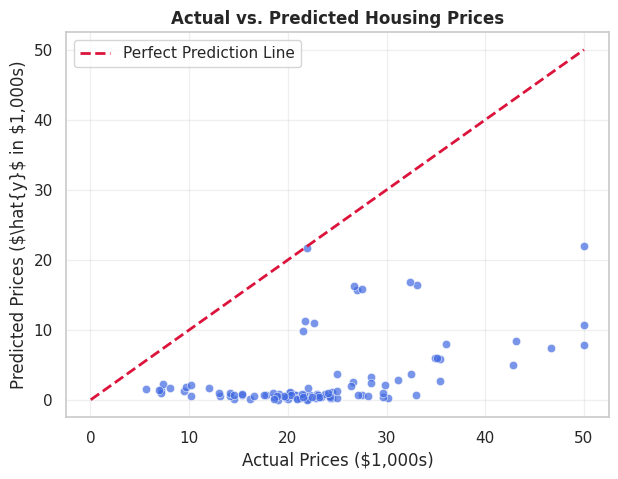

In [50]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(7, 5))
sns.scatterplot(x=y, y=y_hat, alpha=0.7, color='royalblue')

# Add a perfect prediction reference line
max_val = max(max(y), max(y_hat))
min_val = min(min(y), min(y_hat))
plt.plot([min_val, max_val], [min_val, max_val], color='crimson', linestyle='--', linewidth=2, label='Perfect Prediction Line')

plt.title('Actual vs. Predicted Housing Prices', fontsize=12, fontweight='bold')
plt.xlabel('Actual Prices ($1,000s)')
plt.ylabel('Predicted Prices ($\hat{y}$ in $1,000s)')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()
